In [1]:
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import glob,os,sys
from tqdm.auto import tqdm
import proplot as plot
import json,pickle
import dask.array as da
import gc
from sklearn.decomposition import PCA
from tools import derive_var,read_and_proc,preproc_noensemble
from tools.mlr import mlr
from tools.preprocess import do_eof,preproc_maria,preproc_haiyan
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from wrf import getvar, interplevel
from netCDF4 import Dataset
from wrf import getvar, CoordPair, xy_to_ll, ll_to_xy, get_cartopy, latlon_coords
from wrf import to_np

import perturb
%matplotlib inline
plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',
                'tick.labelweight':'ultralight','gridminor.linestyle':'--','title.weight':'normal','linewidth':0.5})
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32"

/tmp/ipykernel_2525874/1435216922.py:29: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',


In [56]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Nimbus Roman', 'Times', 'C059-Roman', 'P052-Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'

# Domain I

In [10]:

# same time axis as d02
t0 = pd.Timestamp("2013-11-01 00:00:00")
t1 = pd.Timestamp("2013-11-05 00:00:00")
times_all = pd.date_range(start=t0, end=t1, freq="15min")
n_time = len(times_all)

with Dataset("LWPERTIN_d01.nc", "w", format="NETCDF4") as nc:
    # ------------------------
    # Dimensions (WRF style)
    # ------------------------
    nc.createDimension("Time", n_time)
    nc.createDimension("DateStrLen", 19)
    nc.createDimension("bottom_top", 54)
    nc.createDimension("south_north", 239)
    nc.createDimension("west_east", 389)

    # ------------------------
    # Times variable
    # ------------------------
    times_var = nc.createVariable("Times", "S1", ("Time", "DateStrLen"))
    for it, tstamp in enumerate(times_all):
        date_str = tstamp.strftime("%Y-%m-%d_%H:%M:%S")
        times_var[it, :] = np.array(list(date_str), dtype="S1")

    # ------------------------
    # LWPERTIN variable (zero field)
    # ------------------------
    lwpertin = nc.createVariable(
        "LWPERTIN", "f4",
        ("Time", "bottom_top", "south_north", "west_east"),
        zlib=True, complevel=4, chunksizes=(1, 1, 239, 389)
    )

    # WRF-style metadata
    lwpertin.FieldType   = 104
    lwpertin.MemoryOrder = "XYZ"
    lwpertin.units       = ""
    lwpertin.description = "LW perturbation field"
    lwpertin.stagger     = ""

    # ------------------------
    # Fill with zeros
    # ------------------------
    zero_block = np.zeros((54, 239, 389), dtype=np.float32)
    for it in tqdm(range(n_time)):
        lwpertin[it, :, :, :] = zero_block

  0%|          | 0/385 [00:00<?, ?it/s]

In [12]:
times_all

DatetimeIndex(['2013-11-01 00:00:00', '2013-11-01 00:15:00',
               '2013-11-01 00:30:00', '2013-11-01 00:45:00',
               '2013-11-01 01:00:00', '2013-11-01 01:15:00',
               '2013-11-01 01:30:00', '2013-11-01 01:45:00',
               '2013-11-01 02:00:00', '2013-11-01 02:15:00',
               ...
               '2013-11-04 21:45:00', '2013-11-04 22:00:00',
               '2013-11-04 22:15:00', '2013-11-04 22:30:00',
               '2013-11-04 22:45:00', '2013-11-04 23:00:00',
               '2013-11-04 23:15:00', '2013-11-04 23:30:00',
               '2013-11-04 23:45:00', '2013-11-05 00:00:00'],
              dtype='datetime64[ns]', length=385, freq='15T')

# Domain II

## Read files

In [2]:
from netCDF4 import Dataset
from wrf import getvar, CoordPair, xy_to_ll, ll_to_xy, get_cartopy, latlon_coords
from wrf import to_np

proc_U = xr.open_dataset("/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/data/haiyan_10memb/memb03/U_HiRes.nc")
proc_V = xr.open_dataset("/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/data/haiyan_10memb/memb03/V_HiRes.nc")
# Get domain settings
ncfile = Dataset("/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/data/haiyan_10memb/memb03/wrfout_d02_2013-11-01_00:00:00")
# Get the Sea Level Pressure
RTHRATLW = getvar(ncfile, "RTHRATLW")
pres = getvar(ncfile, "pres", units="hPa")
# Get TC track
track = xr.open_dataset("/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/data/haiyan_10memb/memb03/track_avor_850-600.nc")

P  = getvar(ncfile, "P").values   # Pa
PB = getvar(ncfile, "PB").values  # Pa
p_eta_full = (P + PB) * 0.01        # hPa, shape (54, 740, 1200)

In [3]:
RTHRATLW.shape

(54, 740, 1200)

## Generate time stamps

In [3]:
import pandas as pd

# Define start and end datetimes
t0 = pd.Timestamp("2013-11-01 00:00:00")
t1 = pd.Timestamp("2013-11-05 00:00:00")

# Generate 1-hr steps (end inclusive)
times_1hr = pd.date_range(start=t0, end=t1, freq="1h")
# Generate 3-min steps (end inclusive)
times_3min = pd.date_range(start=t0, end=t1, freq="3min")

# Format as WRF-style strings
times_str_3min = [t.strftime("%Y-%m-%d_%H:%M:%S") for t in times_3min]
time_str_1hr = [t.strftime("%Y-%m-%d_%H:%M:%S") for t in times_1hr]

## Process and find track indices

### Original time resolution

In [5]:
Xs = []
ys = []
weshape = RTHRATLW.shape[2]
nsshape = RTHRATLW.shape[1]
domainradius = int(200*3/15)
for i in range(len(track['clat'])):
    x,y = ll_to_xy(ncfile, track['clat'][i], track['clon'][i], as_int=True)
    if ((weshape-x)>domainradius) and ((nsshape-y)>domainradius):
        Xs.append(int(x.values))
        ys.append(int(y.values))
    else:
        Xs.append(np.nan)
        ys.append(np.nan)

In [6]:
shear_mags,shear_dirs = [],[]
for i in range(len(track['clat'])):
    if Xs[i]==np.nan:
        shear_mags.append(np.nan)
        shear_dirs.append(np.nan)
    else:
        shear_u, shear_v, shear_mag = perturb.compute_tc_shear(proc_U['U'][i,...], proc_V['V'][i,...], list(proc_U['pres'].data), Xs[i], ys[i], dx_km=3.0,
                                                       inner_km=200.0, outer_km=800.0,
                                                       p_top=200.0, p_bot=850.0)
        shear_mags.append(shear_mag)
        shear_dirs.append((np.degrees(np.arctan2(shear_v, shear_u)) % 360.0))

In [7]:
proc_lw = xr.open_dataset("/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/data/haiyan_10memb/memb03/RTHRATLW_HiRes.nc")
# Defining magnitudes to create perturbations
means,stds = [],[]
for timeloc in range(len(track['clat'])):
    if Xs[timeloc] is not np.nan:
        mean = np.mean(proc_lw['RTHRATLW'][timeloc,:,int(ys[timeloc])-200:int(ys[timeloc])+200,int(Xs[timeloc])-200:int(Xs[timeloc])+200].values,axis=(1,2))
        std = np.std(proc_lw['RTHRATLW'][timeloc,:,int(ys[timeloc])-200:int(ys[timeloc])+200,int(Xs[timeloc])-200:int(Xs[timeloc])+200].values,axis=(1,2))
        means.append(mean)
        stds.append(std)
    else:
        means.append(np.nan)
        stds.append(np.nan)

### Three-mins resolution

In [8]:
Xs_3min = perturb.change_time_resolution_interpolate(times_1hr, times_3min, t0, np.asarray(Xs))
ys_3min = perturb.change_time_resolution_interpolate(times_1hr, times_3min, t0, np.asarray(ys))
sheardirs_3min = perturb.change_time_resolution_interpolate(times_1hr, times_3min, t0, np.asarray(shear_dirs))
lwmean_3min = perturb.change_time_resolution_interpolate(times_1hr, times_3min, t0, (means))
lwstd_3min = perturb.change_time_resolution_interpolate(times_1hr, times_3min, t0, (stds))

# Create wavenumber-1 anomaly

In [4]:
from scipy.interpolate import interp1d
import numpy as np
from tqdm import tqdm

def remap_to_eta(P_block, p_src_hPa, p_eta_block, fill_value=0.0):
    """Remap one (39,ny,nx) block from pressure → eta levels (54,ny,nx)."""
    k_src, ny, nx = P_block.shape
    k_eta = p_eta_block.shape[0]
    out = np.full((k_eta, ny, nx), fill_value, dtype=np.float32)

    # Ensure increasing x for interp
    if p_src_hPa[0] > p_src_hPa[-1]:
        p_src_use = p_src_hPa[::-1]
        P_src_use = P_block[::-1, :, :]
    else:
        p_src_use = p_src_hPa
        P_src_use = P_block

    x_src = np.log(p_src_use)

    for j in range(ny):
        for i in range(nx):
            col = P_src_use[:, j, i]
            if np.all(np.isnan(col)):
                continue
            valid = ~np.isnan(col)
            if np.sum(valid) < 2:
                continue
            f = interp1d(
                x_src[valid], col[valid],
                kind="linear", bounds_error=False, fill_value=fill_value
            )
            out[:, j, i] = f(np.log(p_eta_block[:, j, i]))
    return out

def remap_to_eta_fast(P_block, p_src_hPa, p_eta_block_hPa, fill_value=0.0):
    """
    Vectorized remap from pressure levels -> eta levels.
    P_block:        (k_src, ny, nx)
    p_src_hPa:      (k_src,) monotonic (ascending or descending)
    p_eta_block_hPa:(k_eta, ny, nx)
    Returns:        (k_eta, ny, nx)
    """
    # Ensure ascending pressure for interp
    if p_src_hPa[0] > p_src_hPa[-1]:
        p_src_use = p_src_hPa[::-1]
        P_block   = P_block[::-1, :, :].values
    else:
        p_src_use = p_src_hPa

    # Use log-pressure
    logp_src = np.log(p_src_use)

    k_eta, ny, nx = p_eta_block_hPa.shape
    out = np.full((k_eta, ny, nx), fill_value, dtype=np.float32)

    # Reshape for vectorized np.interp
    logp_eta_flat = np.log(p_eta_block_hPa.reshape(k_eta, -1))  # (k_eta, ny*nx)
    data_flat = P_block.reshape(P_block.shape[0], -1)           # (k_src, ny*nx)

    # Loop only over vertical levels
    for j in range(logp_eta_flat.shape[1]):  
        # Each column is independent, but here it's a tight C loop in numpy
        out[:, j // nx, j % nx] = np.interp(
            logp_eta_flat[:, j],
            logp_src,
            data_flat[:, j],
            left=fill_value,
            right=fill_value
        )

    return out



In [20]:
p_eta_full.shape

(740, 1200)

In [ ]:
Ps, Rs, Vs = [], [], []
p_src_hPa = list(proc_U['pres'].data)  # your source levels
x = np.linspace(-208*3,208*3,416)
y = np.linspace(-208*3,208*3,416)
#z = np.linspace(1000,100,39) 
x0, y0 = 0.0, 0.0
t_cutoff = len(pd.date_range(start=t0, end=pd.Timestamp("2013-11-05 00:00:00"), freq="3min"))

for i in tqdm(range(t_cutoff)):
    if np.isnan(sheardirs_3min[i]):
        Ps.append(np.nan)
        Rs.append(np.nan)
        Vs.append(np.nan)
    else:
        # 1. Generate 39-level perturbation
        P39, R, V = perturb.wavenumber1_field(
            x, y, p_src_hPa, x0, y0,
            radial_kind='gaussian',
            vertical_kind='flat',
            amp_profile=lwmean_3min[i, :] + lwstd_3min[i, :],
            phi0_deg=sheardirs_3min[i],
            a=1.0, b=1.0,
            r0=100, rmax=250
        )

        # 2. Get eta pressures for this block (54,416,416) from wrfinput
        #    (you’ll need to pick the right subdomain later, but if you just want
        #     to remap the core block for now, slice out the center)
        # Example: center domain indices around (ys_3min[i], Xs_3min[i])
        y0i = int(np.round(ys_3min[i]))
        x0i = int(np.round(Xs_3min[i]))
        p_eta_block = p_eta_full[:, y0i-208:y0i+208, x0i-208:x0i+208]

        # 3. Remap to eta levels
        P54 = remap_to_eta_fast(P39, p_src_hPa, p_eta_block, fill_value=0.0)

        # 4. Store
        Ps.append(P54 * -1)  # perturbation sign
        Rs.append(R)

read_and_proc.save_to_pickle(f'./wrf_memb3_wn1_4days_eta.pkl',{'Ps':Ps,'Rs':Rs})

  0%|                                                                                                                                           | 0/1921 [00:00<?, ?it/s]/tmp/ipykernel_3392515/851164238.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y0i = int(np.round(ys_3min[i]))
/tmp/ipykernel_3392515/851164238.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x0i = int(np.round(Xs_3min[i]))
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1921/1921 [27:33<00:00,  1.16it/s]


In [5]:
#del Ps, Rs
#gc.collect()
memb03_dict = read_and_proc.depickle(f'./wrf_memb3_wn1_2days_eta.pkl')
Ps, Rs = memb03_dict['Ps'], memb03_dict['Rs']

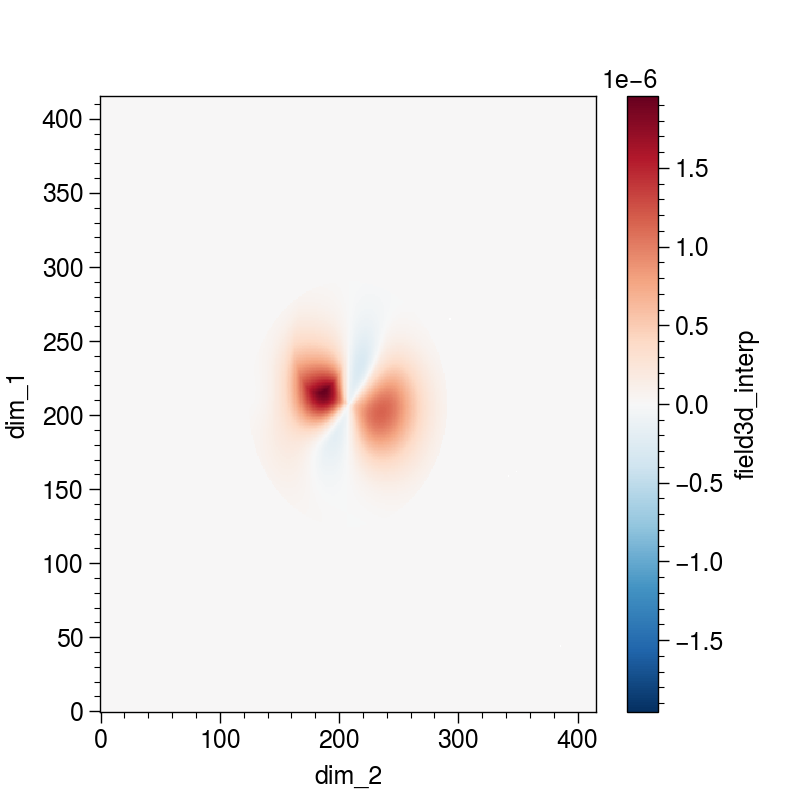

In [51]:
preturb[7].plot()

In [39]:
preturb = [interplevel(Ps[80], P[:,740//2-208:740//2+208,600-208:600+208], pres) for pres in [1000,900,800,700,600,500,400,300,200,100]]

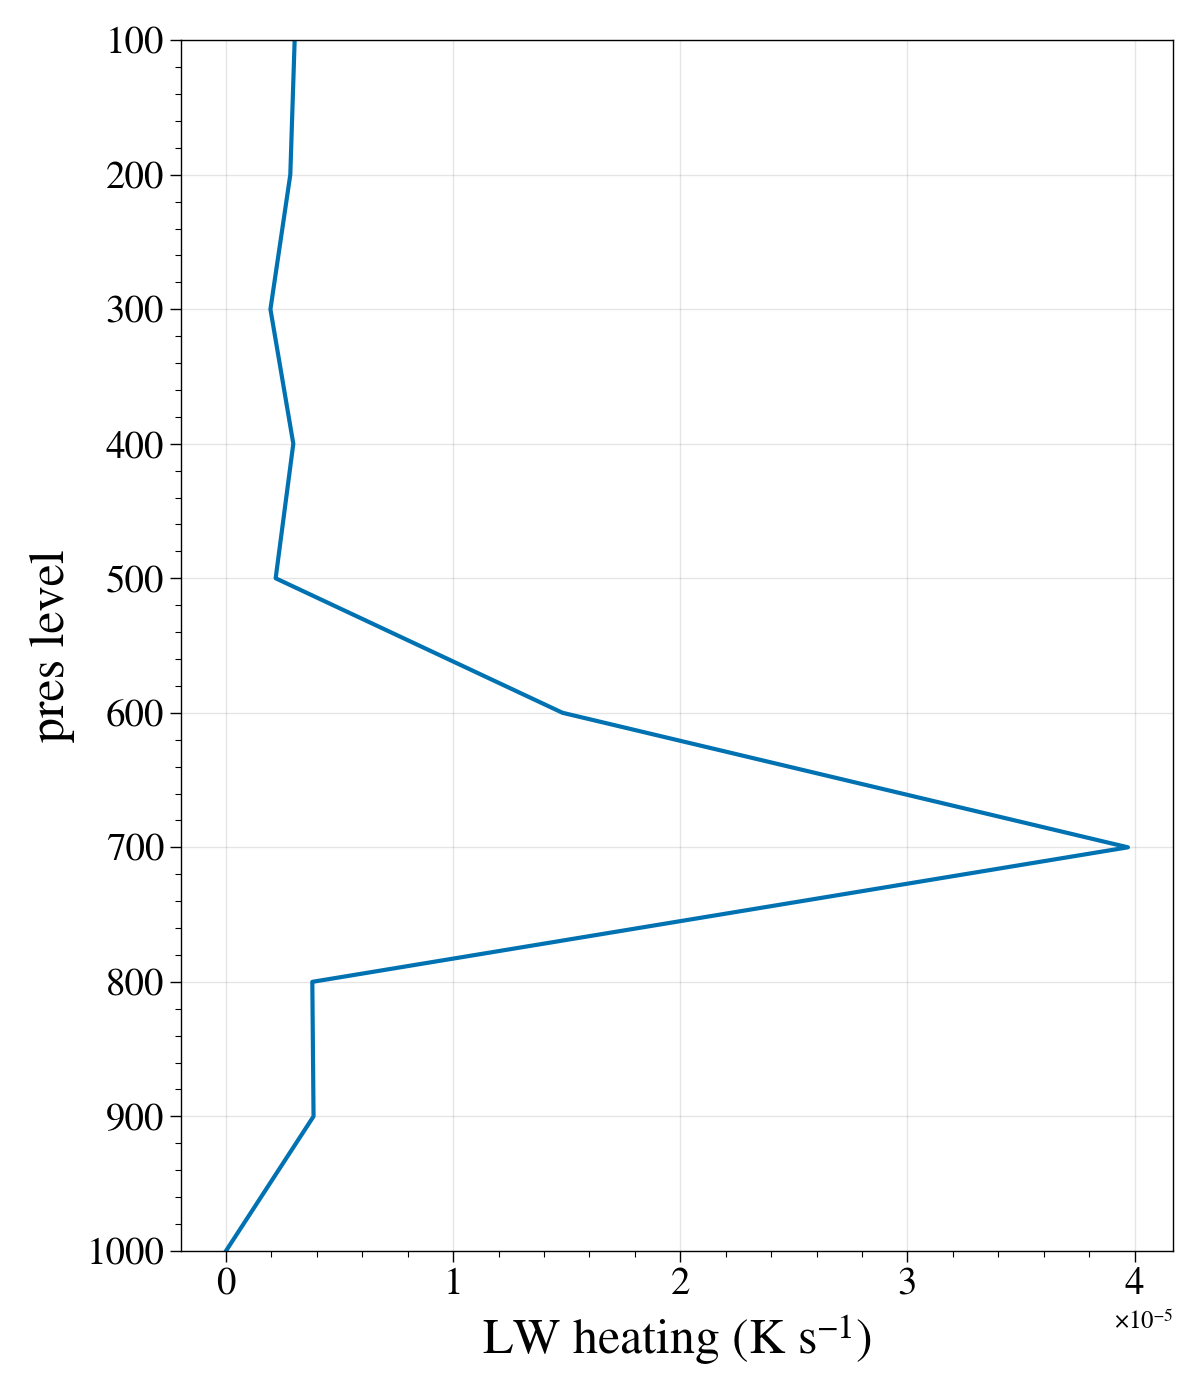

In [64]:
fig,ax = plt.subplots(1,1,figsize=(6,7))
plt.plot(np.nanmax(np.asarray(preturb),axis=(1,2)),[1000,900,800,700,600,500,400,300,200,100])
plt.ylim(1000,100)
plt.ylabel('pres level',size=18)
plt.xlabel('LW heating (K s$^{-1}$)',size=18)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()
#plt.plot(np.max(Ps[70][...],axis=(1,2)),np.linspace(0,53,54))

In [58]:
n_time = 1921
t_cutoff = len(pd.date_range(start=t0, end=pd.Timestamp("2013-11-04 00:00:00"), freq="3min"))

with Dataset("LWPERTIN.nc", "w", format="NETCDF4") as nc:
    # ------------------------
    # Define dimensions (WRF style)
    # ------------------------
    nc.createDimension("Time", n_time)
    nc.createDimension("DateStrLen", 19)
    nc.createDimension("bottom_top", 54)     # <-- use 54 if remapped to eta
    nc.createDimension("south_north", 740)
    nc.createDimension("west_east", 1200)

    # ------------------------
    # Times variable
    # ------------------------
    times_var = nc.createVariable("Times", "S1", ("Time", "DateStrLen"))
    for it, tstamp in enumerate(times_str_3min):
        date_str = tstamp  # already formatted "YYYY-MM-DD_HH:MM:SS"
        times_var[it, :] = np.array(list(date_str), dtype="S1")

    # ------------------------
    # Perturbation variable
    # ------------------------
    lwpertin = nc.createVariable(
        "LWPERTIN", "f4",
        ("Time", "bottom_top", "south_north", "west_east"),
        zlib=True, complevel=4, chunksizes=(1, 1, 416, 416)
    )

    # WRF-style metadata
    lwpertin.FieldType   = 104
    lwpertin.MemoryOrder = "XYZ"
    lwpertin.units       = ""
    lwpertin.description = "LW perturbation field"
    lwpertin.stagger     = ""

    # ------------------------
    # Loop over time
    # ------------------------
    for it, tstamp in enumerate(tqdm(times_str_3min)):
        if it < t_cutoff:
            if np.isnan(Xs_3min[it]):
                lwpertin[it, :, :, :] = 0.0
                continue
            block = Ps[it].astype("float32")  # should be (54, 416, 416) now
            xloc = int(np.round(Xs_3min[it]))
            yloc = int(np.round(ys_3min[it]))
            lwpertin[it, :, yloc-208:yloc+208, xloc-208:xloc+208] = block
        else:
            lwpertin[it, :, :, :] = 0.0

  2%|██▋                                                                                                                               | 40/1921 [00:47<38:08,  1.22s/it]/tmp/ipykernel_3656636/1598016942.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xloc = int(np.round(Xs_3min[it]))
/tmp/ipykernel_3656636/1598016942.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yloc = int(np.round(ys_3min[it]))
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1921/1921 [33:27<00:00,  1.04s/it]


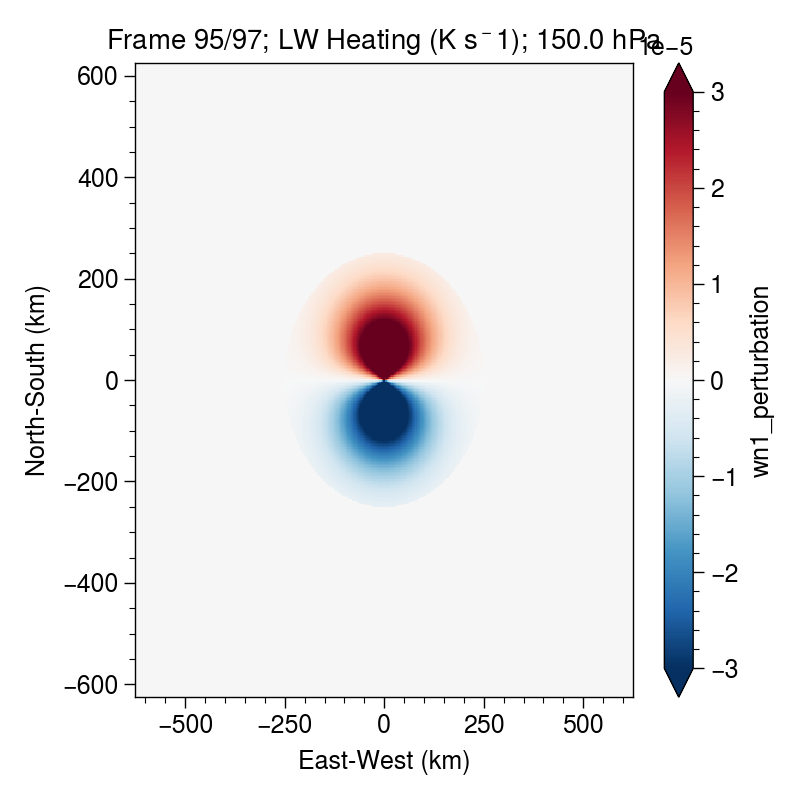

In [147]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

Pss = Ps[2:]
# assume Ps is a list of DataArrays with dims ('y','x') or ('z','y','x')
# you used Ps[50][-5,...], so probably Ps[i][level,...]

level = -5   # vertical level you want
vmin, vmax = -3e-5, 3e-5

fig, ax = plt.subplots()
cmap = "RdBu_r"

# initial frame
im = Pss[0][level,...].plot(
    ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True
)

def update(i):
    ax.clear()
    Pss[i][level,...].plot(
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False
    )
    ax.set_title(f"Frame {i+1}/{len(Ps)}; LW Heating (K s$^{-1}$); {list(proc_U['pres'].data)[-5]} hPa")
    ax.set_ylabel('North-South (km)')
    ax.set_xlabel('East-West (km)')
    return ax

ani = animation.FuncAnimation(
    fig, update, frames=len(Pss), interval=200, blit=False
)
plt.tight_layout()
ani.save("Ps_animation.gif", writer="pillow", dpi=100)
plt.show()


In [2]:
import read_stuff as read
folderpath='/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/TCGphy/2020_TC_CRF/dev/freddy0218/TCG_Rad_keras/store/'
folderpath2='/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/TCGphy/2020_TC_CRF/dev/freddy0218/testML/output/haiyan/processed/new3D/'
so = []
for index in range(40):
    so.append(read._get_exp_name(folderpath2,index,'rhorig','fixTEST')[1])

name = 'HAIYAN'

In [3]:
expnum=17
dataset, dataset_valid, train_loader, val_loader, train_Xtensor, train_ytensor, val_Xtensor,val_ytensor, input_shape, meanstd = read.tensor_prepare(expnum=expnum,
                                                                                                                                           path='/work/FAC/FGSE/IDYST/tbeucler/default/freddy0218/',
                                                                                                                                           suffix='_smooth_preproc_dict1b_g')

In [15]:
toplot = ((train_Xtensor*meanstd['stdX'])+meanstd['meanX'])[50,0,0,...].numpy()

In [16]:
# For radial coordinates -> cartesian conversion
ANGLE = read_and_proc.azimuth2angle(np.linspace(0,359,360))
#apl = (np.fliplr(np.flipud(read_and_proc.proc_tocart(optimized_input.detach().cpu().numpy()[0,0,6,:,:],ANGLE,True,False))))
apl = (np.fliplr(np.flipud(read_and_proc.proc_tocart(toplot,ANGLE,True,False))))

In [42]:
# --- Test with a small grid and random array ---
x = np.linspace(-208*3,208*3,416)
y = np.linspace(-208*3,208*3,416)
z = np.linspace(1000,100,10)

x0, y0 = 0.0, 0.0

perturb, Rweights, Vweights = wavenumber1_field(
    x, y, z, x0, y0,
    amp=np.abs(apl).max(),
    phi0_deg=45,
    a=1.0, b=1.5,
    radial_kind='gaussian',
    r0=100, rmax=300,
    vertical_kind='u_shaped',
    zmid=750, zsig=300,
    low=0.8, high=1.0, minval=0.2
)